# Training Supervised Model

In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import uniform, randint
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, make_scorer
import joblib
import shap
import df2img
import matplotlib.pyplot as plt

In [2]:
# Load data
train = pd.read_csv('../data/train.csv')
train

,num__network_packet_size,num__login_attempts,num__session_duration,num__ip_reputation_score,num__failed_logins,cat__encryption_used_AES,cat__encryption_used_DES,cat__encryption_used_None,cat__browser_type_Chrome,cat__browser_type_Edge,cat__browser_type_Firefox,cat__protocol_type_TCP,cat__protocol_type_UDP,remainder__unusual_time_access,remainder__attack_detected
0,0.496899,-0.016346,-0.381125,1.554930,-0.500779,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0,1
1,-0.143322,-0.525794,0.972960,-0.168029,-1.467959,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0,0
2,0.648132,-0.525794,-0.912503,2.301950,0.466400,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0,1
3,1.530327,-0.016346,-0.243473,-1.174443,-1.467959,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,1
4,-0.239103,0.493102,-0.330830,-1.560484,-0.500779,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9532,-1.544751,-0.525794,-0.720511,1.052117,1.433580,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1
9533,-0.607104,-0.525794,-0.775438,0.435452,-1.467959,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0,0
9534,0.824571,0.493102,-0.963200,0.157266,-0.500779,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0,0
9535,-0.476035,-0.016346,-0.897729,1.163198,-0.500779,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1,0


In [3]:
# Setup pipeline for classification
classifier = Pipeline([
    ('clf', 'passthrough') # Placeholder
])

In [4]:
# Create scorer
f1_scorer = make_scorer(f1_score, average='binary')

In [5]:
# Split data for training and testing
# Acquire target
y = train[['remainder__attack_detected']]
X = train.drop('remainder__attack_detected', axis = 1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Four models with different approaches to supervised learning will be evaluated via hyperparameter tuning. The models are logistic regression, random forest, support vector machines and a multi-layer perceptron classifier neural network.

In [6]:
# Setup hyperparameter tuning for multiple models
param_dist = [
    {
        'clf': [LogisticRegression(random_state=42)],
        'clf__solver': ['liblinear', 'lbgfs'],
        'clf__C': uniform(0,1),
        'clf__l1_ratio': uniform(0,1)
    },
    {
        'clf': [RandomForestClassifier(random_state=42)],
        'clf__n_estimators' : randint(1,200),
        'clf__criterion' : ['gini' , 'entropy', 'log_loss'],
        'clf__max_features': ['sqrt', 'log2', None],
        'clf__min_samples_leaf': uniform(0,1)
    },
    {
        'clf': [SVC(random_state=42)],
        'clf__C': uniform(0,1),
        'clf__kernel': ['linear', 'poly', 'rbf'],
        'clf__degree': randint(1,10),
    },
    {
        'clf': [MLPClassifier(random_state=42)],
        'clf__activation': ['relu', 'tanh', 'logistic', 'identity'],
        'clf__solver' : ['lbgfs', 'sgd', 'adam'],
        'clf__alpha': uniform(0,1),
        'clf__learning_rate' : ['constant', 'invscaling', 'adaptive']
    }
    
]

Since Company A desires to minimize both false negatives and false positives, f1 score will be used as the metrics for choosing the model. Due  to computational constraints, randomized search will be used instead of grid search.

In [7]:
#Build  the random searcher
random_search = RandomizedSearchCV(
    estimator=classifier,
    param_distributions=param_dist,
    cv=5,
    random_state=42,
    scoring=f1_scorer
)

In [8]:
# Do the random search
random_search.fit(X_train,y_train.values.ravel())

/opt/conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/numpy/ma/core.p

RandomizedSearchCV(cv=5, estimator=Pipeline(steps=[('clf', 'passthrough')]),
                   param_distributions=[{'clf': [LogisticRegression(random_state=42)],
                                         'clf__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x77cb7c57db80>,
                                         'clf__l1_ratio': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x77cb7c57d340>,
                                         'clf__solver': ['liblinear',...
                                        {'clf': [MLPClassifier(random_state=42)],
                                         'clf__activation': ['relu', 'tanh',
                                                             'logistic',
                                                             'identity'],
                                         'clf__alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x77cb7cf88530>,
                                         'clf__learning_rate': ['constant',
                                                                'invscaling',
                                                                'adaptive'],
                                         'clf__solver': ['lbgfs', 'sgd',
                                                         'adam']}],
                   random_state=42,
                   scoring=make_scorer(f1_score, response_method='predict', average=binary))

The chosen estimator is SVC.

In [9]:
joblib.dump(random_search, '../models/supervised.joblib')

['../models/supervised.joblib']

In [10]:
best_model = random_search.best_estimator_

In [11]:
random_search.best_score_

0.824288158458263

In [12]:
random_search.best_params_

{'clf': SVC(random_state=42),
 'clf__C': 0.8661761457749352,
 'clf__degree': 4,
 'clf__kernel': 'rbf'}

In [13]:
def evaluate_model(y_true, y_pred, average='binary'):
    """
    Computes and prints accuracy, precision, recall, and F1 score and returns a Pandas DataFrame
    """
    metrics = {
    "Accuracy": accuracy_score(y_true, y_pred),
    "Precision": precision_score(y_true, y_pred, average="binary"),
    "Recall": recall_score(y_true, y_pred, average="binary"),
    "F1 Score": f1_score(y_true, y_pred, average="binary")
    }

    metrics_df = pd.DataFrame(list(metrics.items()), columns=["Metric", "Score"])
    return metrics_df

In [14]:
y_pred = random_search.predict(X_test)

In [15]:
metrics = evaluate_model(y_test,y_pred)
metrics


,Metric,Score
0,Accuracy,0.862159
1,Precision,0.963134
2,Recall,0.724018
3,F1 Score,0.826632


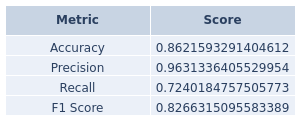

In [16]:
# Save dataframe
fig_metrics = df2img.plot_dataframe(metrics, print_index= False, fig_size=(300, 140))
df2img.save_dataframe(fig=fig_metrics, filename='../images/metrics.png')

In [17]:
# Use shap to explain model decisions
explainer = shap.Explainer(best_model.predict, X_train)
shap_values = explainer(X_test)

PermutationExplainer explainer: 1909it [3:03:00,  5.76s/it]                            


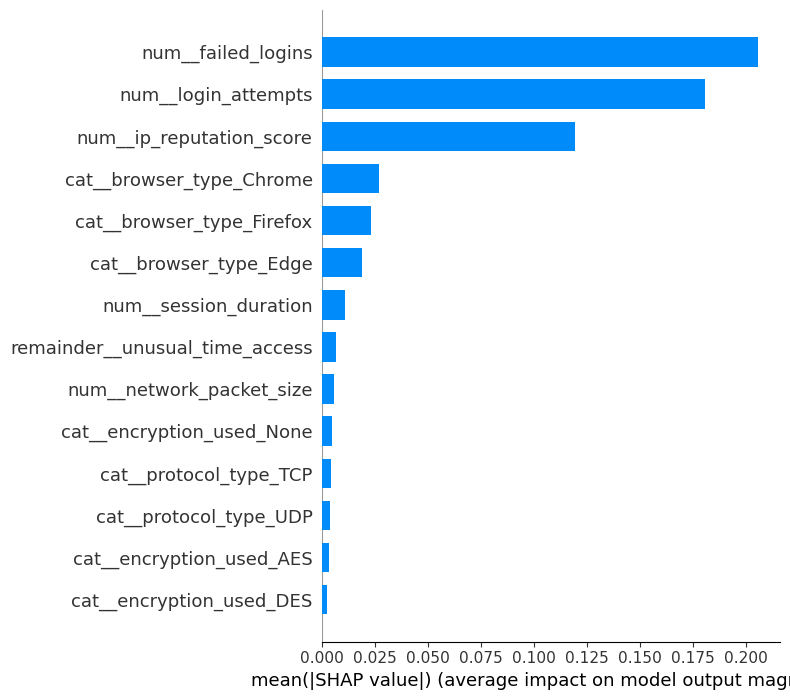

In [18]:
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.savefig('../images/shap_summary.png')
plt.show()

It can be seen that the most important features are the number of login attempts, failed login attempts and IP reputation score.

While the model performed remarkably well, it can be seen that the model is biased to Dictionary Attacks due to the high feature importance of login attempts and failed login attempts. Attacks such as DDoS and vulnerability exploits may not be detected by the model. Since the model is supervised, it cannot detect unattested forms of attack.